In [ ]:
# UAE Real Estate Analysis

## Project Objective

This project analyzes real estate market data in the UAE to identify pricing patterns, property trends, and factors affecting property values.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/uae_real_estate_2024.csv')
df.head(5)

,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
0,Great ROI I High Floor I Creek View,"Binghatti Canal, Business Bay, Dubai",3,2,2024-08-14T12:02:53Z,Residential for Sale,2500000,True,sell,1323 sqft,NO,MNA Properties is delighted to offer this apar...
1,Full Sea View | Beach Life | Brand New Residence,"La Vie, Jumeirah Beach Residence, Dubai",3,2,2024-08-13T05:45:16Z,Residential for Sale,7200000,True,sell,1410 sqft,YES,"Apartment for sale in La Vie, Jumeirah Beach R..."
2,Green Belt | Corner Unit | Spacious Plot,"La Rosa 6, Villanova, Dubai Land, Dubai",3,4,2024-08-14T06:24:28Z,Residential for Sale,3600000,True,sell,2324 sqft,NO,Treo Homes is very pleased to be bringing to t...
3,2BR+Study | Near Pool and Park | Private,"Springs 15, The Springs, Dubai",3,2,2024-08-15T06:07:22Z,Residential for Sale,2999999,True,sell,1647 sqft,NO,2 Bedrooms + Study | Near Pool &amp; Park | Pr...
4,Vacant | Well Maintained | Area Expert,"Noor Townhouses, Town Square, Dubai",3,3,2024-08-09T08:28:59Z,Residential for Sale,2449999,True,sell,2105 sqft,NO,-Type 1\n-3 Bed+Maid\n-Close To Amenities\n-BU...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           5058 non-null   object
 1   displayAddress  5058 non-null   object
 2   bathrooms       4938 non-null   object
 3   bedrooms        4935 non-null   object
 4   addedOn         5058 non-null   object
 5   type            5058 non-null   object
 6   price           5058 non-null   int64 
 7   verified        5058 non-null   bool  
 8   priceDuration   5058 non-null   object
 9   sizeMin         5058 non-null   object
 10  furnishing      5056 non-null   object
 11  description     5057 non-null   object
dtypes: bool(1), int64(1), object(10)
memory usage: 439.7+ KB


In [ ]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           5058 non-null   object
 1   displayAddress  5058 non-null   object
 2   bathrooms       4938 non-null   object
 3   bedrooms        4935 non-null   object
 4   addedOn         5058 non-null   object
 5   type            5058 non-null   object
 6   price           5058 non-null   int64 
 7   verified        5058 non-null   bool  
 8   priceDuration   5058 non-null   object
 9   sizeMin         5058 non-null   object
 10  furnishing      5056 non-null   object
 11  description     5057 non-null   object
dtypes: bool(1), int64(1), object(10)
memory usage: 439.7+ KB


In [ ]:
df.isnull().sum()

,0
title,0
displayAddress,0
bathrooms,120
bedrooms,123
addedOn,0
type,0
price,0
verified,0
priceDuration,0
sizeMin,0


<ipython-input-6-be72f8e3b18b>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=furnishing.index, y=furnishing.values, palette='pastel')


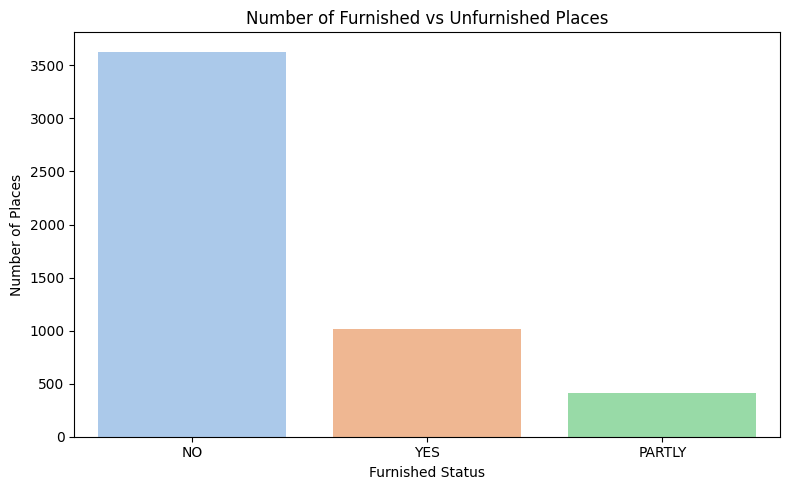

In [ ]:
#nom of furnished places
furnishing = df['furnishing'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=furnishing.index, y=furnishing.values, palette='pastel')
plt.title('Number of Furnished vs Unfurnished Places')
plt.xlabel('Furnished Status')
plt.ylabel('Number of Places')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<ipython-input-7-0b6fa4659858>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='displayAddress', data=address_price.head(20), palette='viridis')


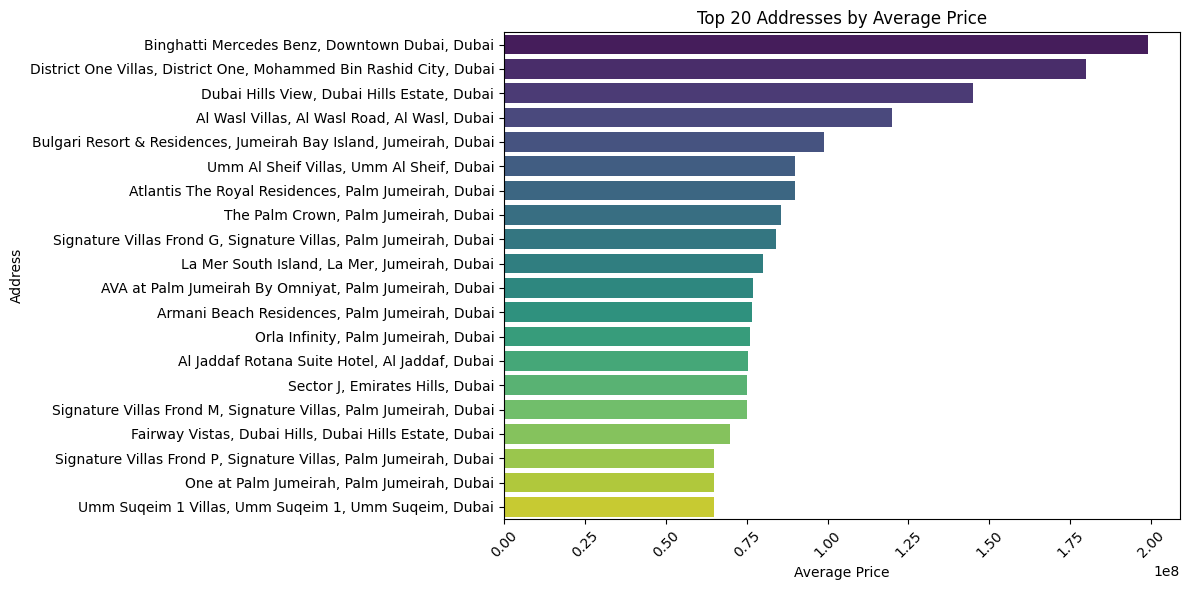

In [ ]:
#address and price

address_price = df.groupby('displayAddress')['price'].max().reset_index()
address_price = address_price.sort_values(by='price', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='price', y='displayAddress', data=address_price.head(20), palette='viridis')
plt.title('Top 20 Addresses by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Address')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

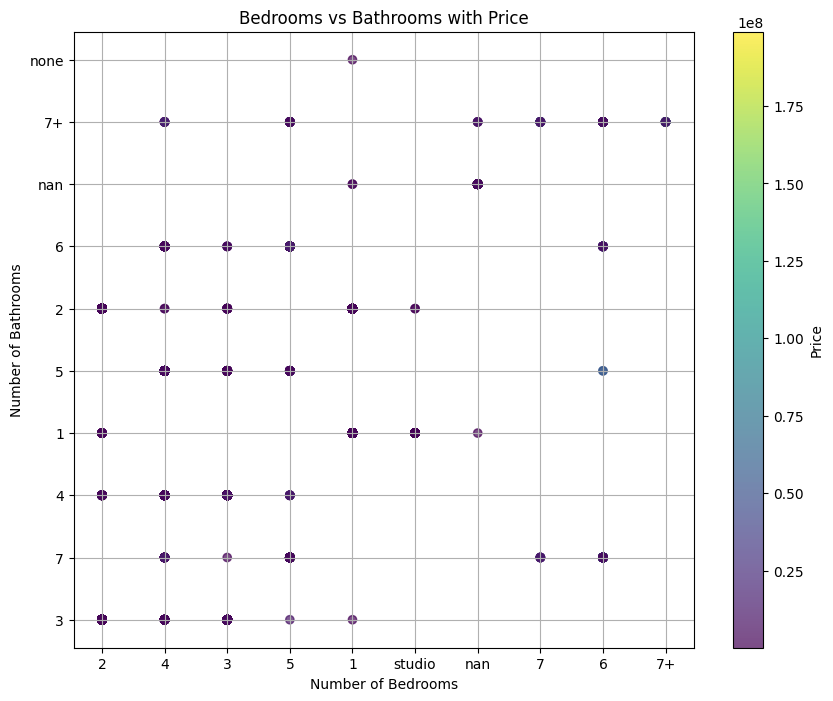

In [ ]:
#bedr and bathr with price 1
df['bedrooms'] = df['bedrooms'].astype(str)
df['bathrooms'] = df['bathrooms'].astype(str)

df['price'] = df['price'].astype(float)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data=df, x='bedrooms', y='bathrooms', c='price', cmap='viridis', alpha=0.7)

cbar = plt.colorbar(scatter)
cbar.set_label('Price')
plt.title('Bedrooms vs Bathrooms with Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Bathrooms')
plt.grid(True)

plt.show()

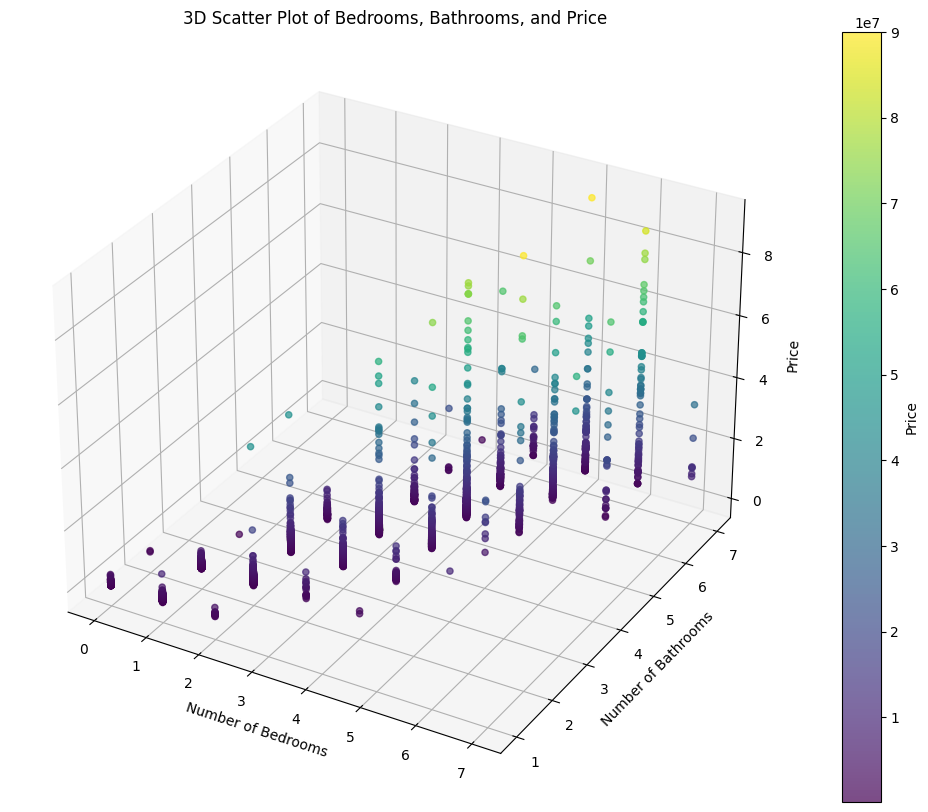

In [ ]:
#bedr and bathr with price 2chatgbt
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce').fillna(0)
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['bedrooms'], df['bathrooms'], df['price'], c=df['price'], cmap='viridis', alpha=0.7)

ax.set_title('3D Scatter Plot of Bedrooms, Bathrooms, and Price')
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Number of Bathrooms')
ax.set_zlabel('Price')
cbar = plt.colorbar(scatter)
cbar.set_label('Price')
plt.show()

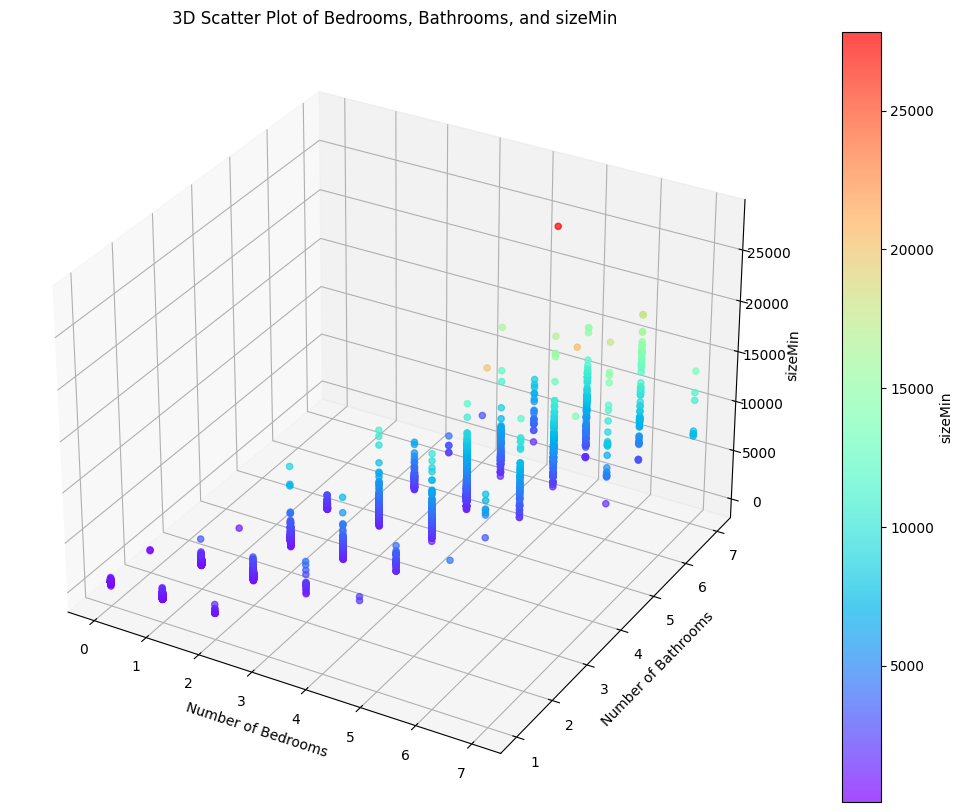

In [ ]:
#bedr and bathr and the size
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce').fillna(0)
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')
df['sizeMin'] = df['sizeMin'].str.extract('(\d+)').astype(float)

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['bedrooms'], df['bathrooms'], df['sizeMin'], c=df['sizeMin'], cmap='rainbow', alpha=0.7)

ax.set_title('3D Scatter Plot of Bedrooms, Bathrooms, and sizeMin')
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Number of Bathrooms')
ax.set_zlabel('sizeMin')
cbar = plt.colorbar(scatter)
cbar.set_label('sizeMin')
plt.show()

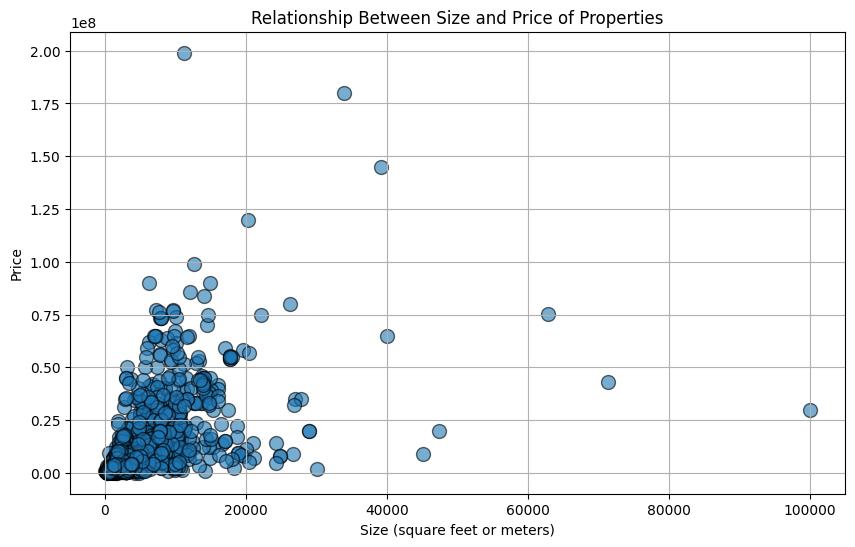

In [ ]:
#size and price
plt.figure(figsize=(10, 6))
plt.scatter(df['sizeMin'], df['price'], alpha=0.6, edgecolors='k', s=100)

plt.title('Relationship Between Size and Price of Properties')
plt.xlabel('Size (square feet or meters)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

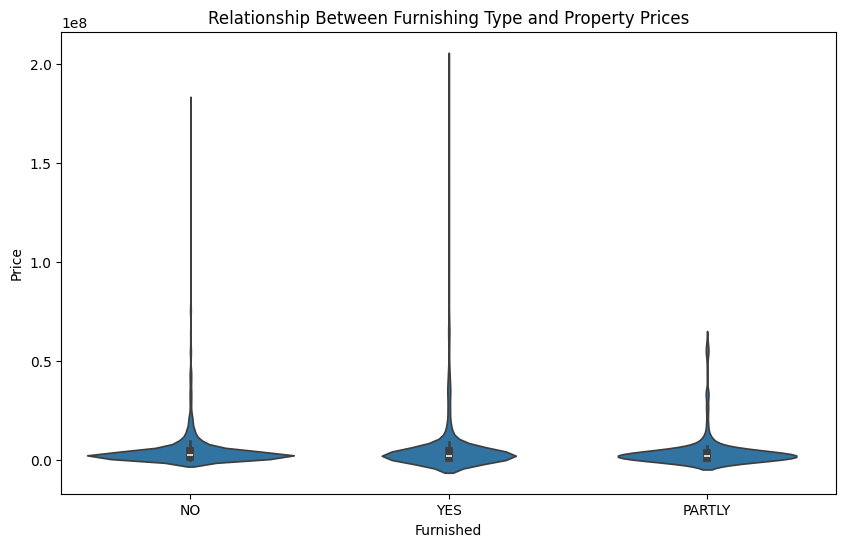

In [ ]:
df = pd.DataFrame(df)
plt.figure(figsize=(10, 6))
sns.violinplot(x='furnishing', y='price', data=df)
plt.title('Relationship Between Furnishing Type and Property Prices')
plt.xlabel('Furnished')
plt.ylabel('Price')
plt.show()

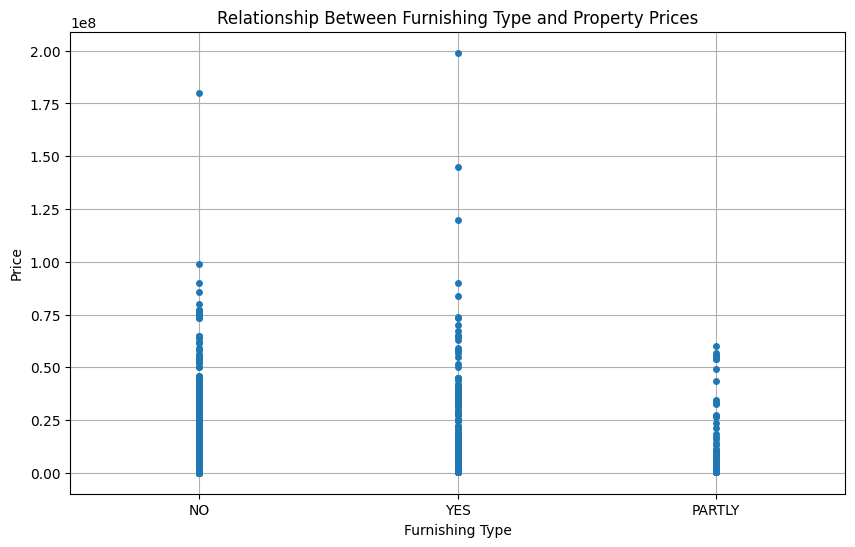

In [ ]:
df = pd.DataFrame(df)
plt.figure(figsize=(10, 6))
sns.stripplot(x='furnishing', y='price', data=df, jitter=False)
plt.title('Relationship Between Furnishing Type and Property Prices')
plt.xlabel('Furnishing Type')
plt.ylabel('Price')
plt.grid(True)
plt.show()